Verifying raw data shapes: (786432,)
Real cosmic shear value scale check: Min=-0.0107, Max=0.0164


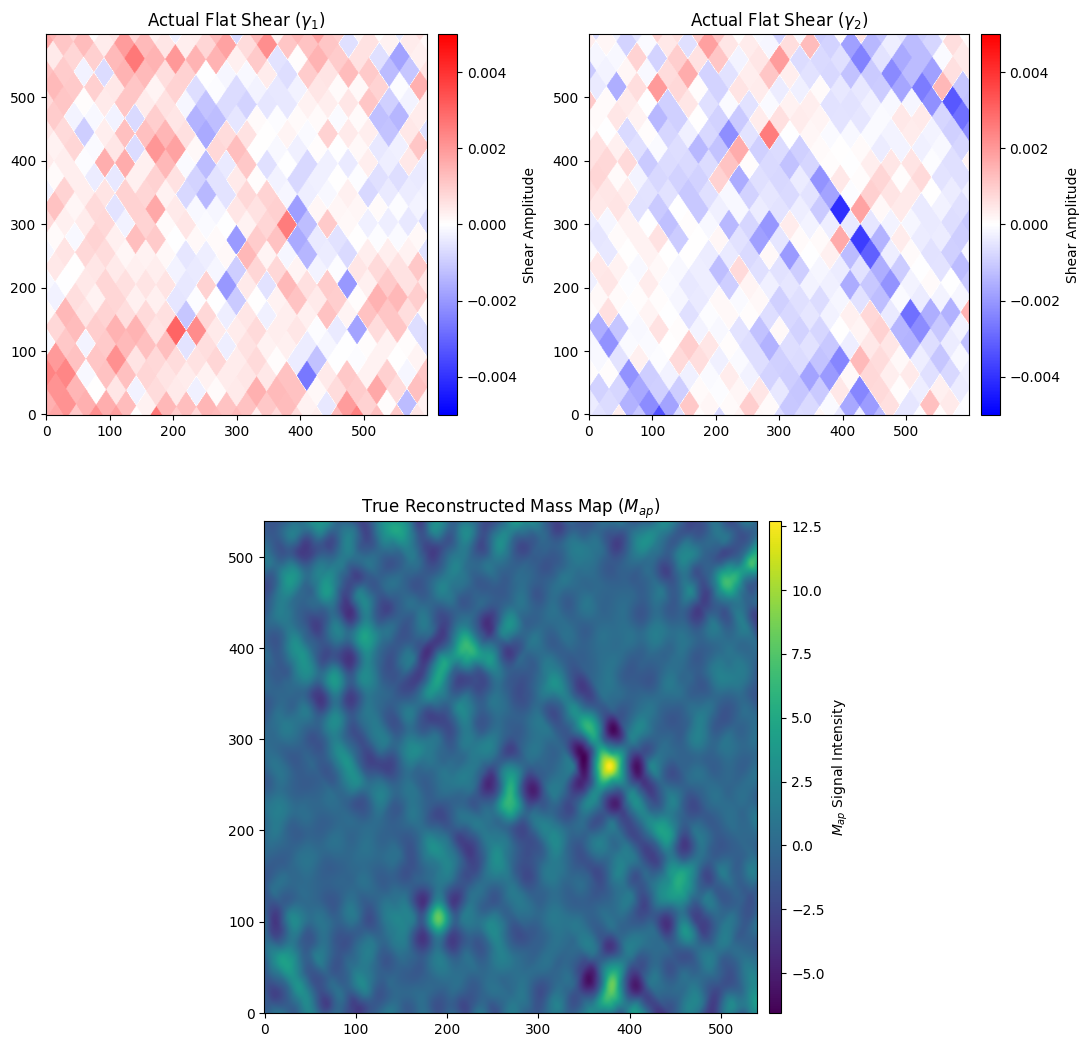

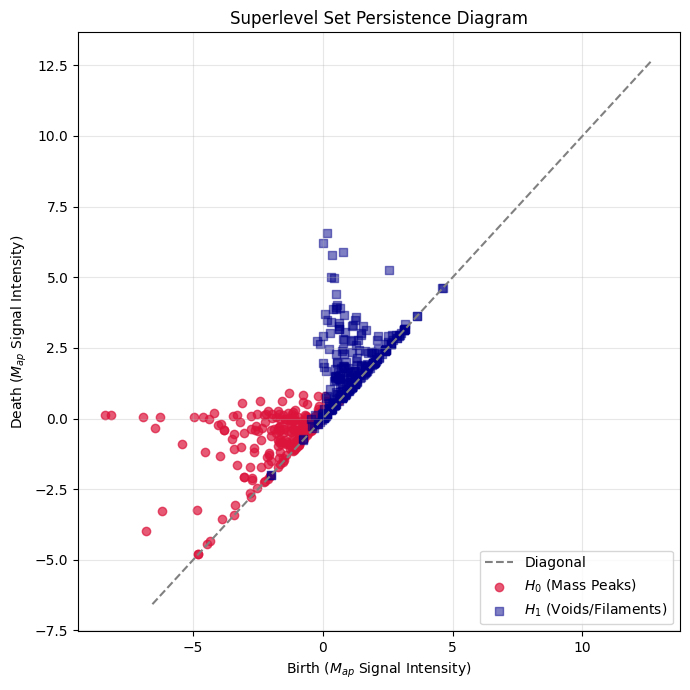

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from scipy.signal import fftconvolve
import gudhi as gd

# 1. Load data explicitly to clear old memory
g1_raw = np.load("gamma1.npy")
g2_raw = np.load("gamma2.npy")

print(f"Verifying raw data shapes: {g1_raw.shape}")
print(f"Real cosmic shear value scale check: Min={g1_raw.min():.4f}, Max={g1_raw.max():.4f}")

# Step 2
ra0, dec0 = 45, 45
mapsize = 5 
res_arcmin = 0.5 
Npix = int(mapsize * 60 / res_arcmin)

# step 3: Project HEALPix to flat maps
plt.figure(figsize=(1,1))
g1_flat = hp.gnomview(g1_raw, rot=[ra0, dec0], xsize=Npix, reso=res_arcmin, return_projected_map=True)
g2_flat = hp.gnomview(g2_raw, rot=[ra0, dec0], xsize=Npix, reso=res_arcmin, return_projected_map=True)
plt.close('all')

# Schirmer kernel setup (Hetterscheidt et al. 2005)
def schirmer_kernel(x):
    a, b, c, d, x_c = 6.0, 150.0, 50.0, 0.75, 0.1
    x = np.where(x == 0, 1e-5, x)
    return (x / x_c) * (1.0 / (1.0 + np.exp(a - b*x) + np.exp(c*(x - d))))

# step 4: Construct the Filter Kernels
R_pix = 30 
y_idx, x_idx = np.indices((2 * R_pix + 1, 2 * R_pix + 1))
dy, dx = y_idx - R_pix, x_idx - R_pix
r_distances = np.sqrt(dx**2 + dy**2)
normalized_r = r_distances / R_pix

# Compute standard angles
phi = np.arctan2(dy, dx)
cos_2phi = np.cos(2 * phi)
sin_2phi = np.sin(2 * phi)

aperture_mask = r_distances <= R_pix
W = schirmer_kernel(normalized_r) * aperture_mask

# Split the tangential shear equation components into distinct spatial filters
# Recall: M_ap = \int W * \gamma_t = \int W * (-\gamma_1*cos2phi - \gamma_2*sin2phi)
kernel_1 = cos_2phi * W
kernel_2 = sin_2phi * W

# step 5: Lightning Fast 2D Convolution (Replaces nested loops)
# Using mode='same' keeps dimensions identical to Npix
Map_matrix_1 = fftconvolve(g1_flat, kernel_1, mode='same')
Map_matrix_2 = fftconvolve(g2_flat, kernel_2, mode='same')
Map_matrix = Map_matrix_1 + Map_matrix_2

# Crop the invalid borders where the kernel fell off the boundaries
cropped_map = Map_matrix[R_pix : Npix - R_pix, R_pix : Npix - R_pix]


# STEP 6: VISUALIZE WITH PERFECT SYMMETRY (VERTICAL COLORBAR FIX)

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs = plt.subplot_mosaic([['shear1', 'shear2'], 
                               ['mass', 'mass']], 
                              figsize=(11, 11))

# 1. Top-Left Panel: Gamma 1
im1 = axs['shear1'].imshow(g1_flat, cmap='bwr', origin='lower', vmin=-0.005, vmax=0.005)
axs['shear1'].set_title("Actual Flat Shear ($\gamma_1$)")

divider1 = make_axes_locatable(axs['shear1'])
cax1 = divider1.append_axes("right", size="5%", pad="3%")
fig.colorbar(im1, cax=cax1, label='Shear Amplitude')


# 2. Top-Right Panel: Gamma 2
im2 = axs['shear2'].imshow(g2_flat, cmap='bwr', origin='lower', vmin=-0.005, vmax=0.005)
axs['shear2'].set_title("Actual Flat Shear ($\gamma_2$)")

divider2 = make_axes_locatable(axs['shear2'])
cax2 = divider2.append_axes("right", size="5%", pad="3%")
fig.colorbar(im2, cax=cax2, label='Shear Amplitude')


# 3. Bottom Panel: Full-Width Reconstructed Aperture Mass Map
cropped_map = Map_matrix[R_pix : Npix - R_pix, R_pix : Npix - R_pix]
im3 = axs['mass'].imshow(cropped_map, cmap='viridis', origin='lower')
axs['mass'].set_title("True Reconstructed Mass Map ($M_{ap}$)")

divider3 = make_axes_locatable(axs['mass'])
cax3 = divider3.append_axes("right", size="2.5%", pad="2.5%")
fig.colorbar(im3, cax=cax3, label='$M_{ap}$ Signal Intensity')

plt.tight_layout()
plt.savefig('cosmic_reconstruction_perfect_align.pdf', bbox_inches='tight', dpi=300)
plt.show()

# --- 1. Map Preprocessing ---
# GUDHI's CubicalComplex default sweep runs from low-to-high values (sublevel set).
# To perform a SUPERLEVEL set filtration sweep (high-to-low), we simply invert 
# the sign of our map data. 
superlevel_map = -cropped_map

# --- 2. Construct Cubical Complex ---
# We pass the dimensions and the flattened inverted array
dimensions = superlevel_map.shape
cubical_complex = gd.CubicalComplex(dimensions=dimensions, top_dimensional_cells=superlevel_map.flatten())

# --- 3. Compute Persistence ---
persistence = cubical_complex.persistence()

# --- 4. Revert the Sign Mismatch for Plotting ---
# Because we inverted the map, the birth/death values are flipped and negative.
# We modify the persistence pairs back to the true Map Intensity scale.
corrected_persistence = []
for dimension, (birth, death) in persistence:
    # In a superlevel set, features are born at HIGHER values and die at LOWER values.
    # If death is infinity (the global maximum peak that never dies), keep it as inf.
    true_birth = birth
    true_death = death if death != float('inf') else float('-inf')
    corrected_persistence.append((dimension, (true_birth, true_death)))

# --- 5. Visualize the Persistence Diagram ---
fig, ax = plt.subplots(figsize=(7, 7))

# Separate 0-dimensional features (Mass Peaks) and 1-dimensional features (Filaments/Voids loops)
b_0, d_0 = [], []
b_1, d_1 = [], []

for dim, (b, d) in corrected_persistence:
    if dim == 0:
        # Avoid p
        # lotting the one feature that dies at -inf to keep the plot clean
        if d != float('-inf'):
            b_0.append(b)
            d_0.append(d)
    elif dim == 1:
        b_1.append(b)
        d_1.append(d)

# Plot Diagonal (Birth = Death line)
min_val = np.min(cropped_map)
max_val = np.max(cropped_map)
ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', label='Diagonal')

# Plot Topological Features
ax.scatter(b_0, d_0, color='crimson', marker='o', alpha=0.7, label=r'$H_0$ (Mass Peaks)')
ax.scatter(b_1, d_1, color='darkblue', marker='s', alpha=0.5, label=r'$H_1$ (Voids/Filaments)')

ax.set_title("Superlevel Set Persistence Diagram")
ax.set_xlabel("Birth ($M_{ap}$ Signal Intensity)")
ax.set_ylabel("Death ($M_{ap}$ Signal Intensity)")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('persistence_diagram.pdf', bbox_inches='tight', dpi=300)
plt.show()